<a href="https://colab.research.google.com/github/SP4567/Machine_Learning_-_Artificial_Neural_Network/blob/main/Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [288]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [289]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/CAR DETAILS FROM CAR DEKHO.csv")

In [290]:
df.head(5)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [291]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [292]:
df.isnull().value_counts()

,,,,,,,,count
name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,
False,False,False,False,False,False,False,False,4340


In [293]:
df.isna().value_counts()

,,,,,,,,count
name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,
False,False,False,False,False,False,False,False,4340


In [294]:
df.describe()

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


/tmp/ipython-input-2988545071.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'fuel', data = df, palette = ['Lightblue',


<Axes: xlabel='fuel', ylabel='count'>

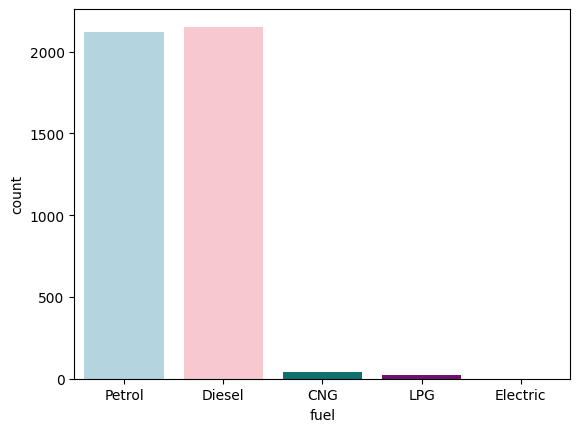

In [295]:
sns.countplot(x = 'fuel', data = df, palette = ['Lightblue',
'Pink',
'Teal',
'Purple',
'Orange'])

In [296]:
df['fuel'].value_counts()

,count
fuel,
Diesel,2153
Petrol,2123
CNG,40
LPG,23
Electric,1


<Axes: xlabel='transmission', ylabel='selling_price'>

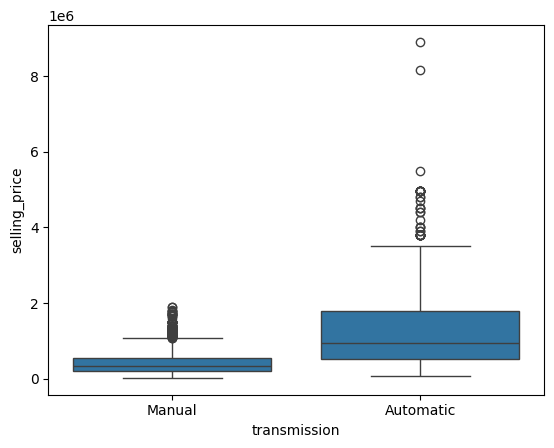

In [297]:
sns.boxplot(x = df['transmission'], y = df['selling_price'])

<Axes: xlabel='seller_type', ylabel='selling_price'>

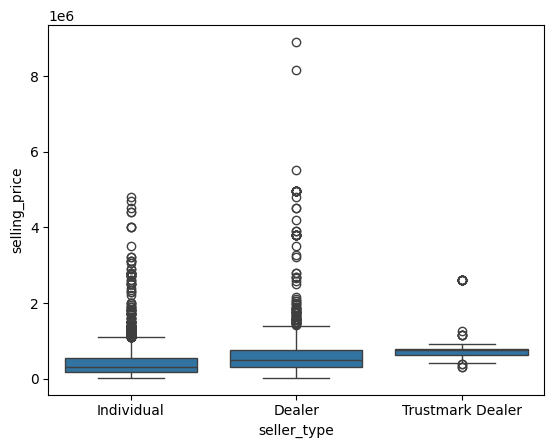

In [298]:
sns.boxplot(x = df['seller_type'], y = df['selling_price'])

<Axes: xlabel='seller_type', ylabel='selling_price'>

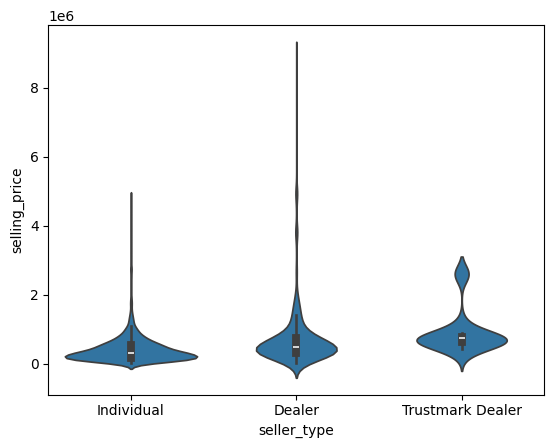

In [299]:
sns.violinplot(x = df['seller_type'], y = df['selling_price'])

<Axes: xlabel='transmission', ylabel='selling_price'>

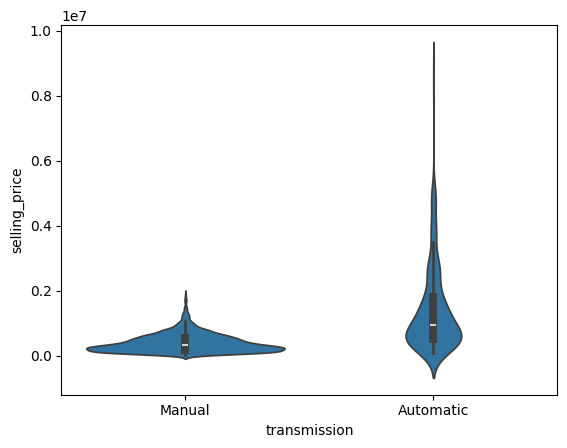

In [300]:
sns.violinplot(x = df['transmission'], y = df['selling_price'])

In [301]:
ohe = OneHotEncoder()
fuel_type = ohe.fit_transform(df[['fuel']]).toarray()
seller = ohe.fit_transform(df[['seller_type']]).toarray()
transmissions = ohe.fit_transform(df[['transmission']]).toarray()
owner_type = ohe.fit_transform(df[['owner']]).toarray()
names = ohe.fit_transform(df[['name']]).toarray()

In [302]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# Temporarily re-instantiate OneHotEncoder for each column to get correct categories for DataFrame creation
# This assumes the numpy arrays 'fuel', 'seller', 'transmission', 'owner', 'name' are already correctly generated
# from the previous cell's OneHotEncoder.

# Get categories for 'fuel'
temp_ohe_fuel = OneHotEncoder()
temp_ohe_fuel.fit(df[['fuel']])
fuel_columns = temp_ohe_fuel.categories_[0]

# Get categories for 'seller_type'
temp_ohe_seller = OneHotEncoder()
temp_ohe_seller.fit(df[['seller_type']])
seller_columns = temp_ohe_seller.categories_[0]

# Get categories for 'transmission'
temp_ohe_transmission = OneHotEncoder()
temp_ohe_transmission.fit(df[['transmission']])
transmission_columns = temp_ohe_transmission.categories_[0]

# Get categories for 'owner'
temp_ohe_owner = OneHotEncoder()
temp_ohe_owner.fit(df[['owner']])
owner_columns = temp_ohe_owner.categories_[0]

# Get categories for 'name'
temp_ohe_name = OneHotEncoder()
temp_ohe_name.fit(df[['name']])
name_columns = temp_ohe_name.categories_[0]

# Create the DataFrames using the pre-transformed numpy arrays and the correctly retrieved column names
fuel_type = pd.DataFrame(fuel_type, columns=fuel_columns)
seller = pd.DataFrame(seller, columns=seller_columns)
transmissions = pd.DataFrame(transmissions, columns=transmission_columns)
owner_type = pd.DataFrame(owner_type, columns=owner_columns)
names = pd.DataFrame(names, columns=name_columns)

In [303]:
df = pd.concat([df, fuel_type, seller, transmissions, owner_type, names], axis = 1)

In [304]:
df.shape

(4340, 1514)

In [305]:
df = df.drop(['fuel', 'seller_type', 'transmission', 'owner', 'name'], axis = 1)

In [306]:
df.shape

(4340, 1509)

In [307]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Columns: 1509 entries, year to Volvo XC60 D5 Inscription
dtypes: float64(1506), int64(3)
memory usage: 50.0 MB


In [308]:
X = df.drop(['selling_price'], axis = 1)
y = df['selling_price']

In [309]:
X.shape

(4340, 1508)

In [310]:
y.shape

(4340,)

In [311]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33)

In [312]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(2907, 1508)
(1433, 1508)
(2907,)
(1433,)


In [313]:
sc = StandardScaler()

In [314]:
X_train_Scaled = sc.fit_transform(X_train)
X_test_Scaled = sc.transform(X_test)

In [315]:
linearRegression = LinearRegression()
linearRegression.fit(X_train_Scaled, y_train)
linearRegression.score(X_train_Scaled, y_train)

0.9812415118948855

In [316]:
y_pred = linearRegression.predict(X_test_Scaled)

In [317]:
y_pred

array([548011.66246845, 445881.50687078, 341139.50827602, ...,
       707711.43118865, 618974.83836794, 209846.6362513 ])

In [318]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(mse)
print(mae)
print(r2)

94752985068.41945
115781.56138082226
0.7421344373565644


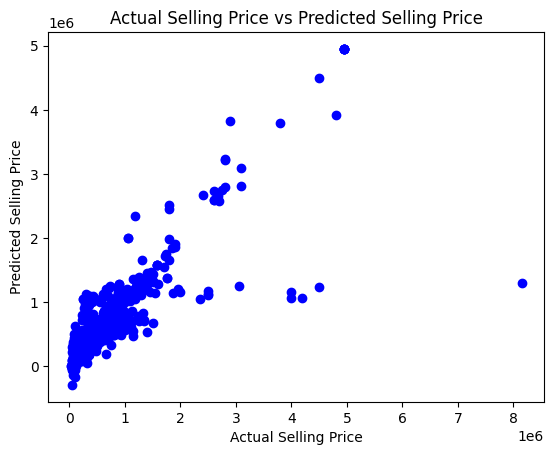

In [319]:
plt.scatter(y_test, y_pred, marker='o', color='blue')
plt.title('Actual Selling Price vs Predicted Selling Price')
plt.ylabel('Predicted Selling Price')
plt.xlabel('Actual Selling Price')
plt.show()

In [320]:
df2 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/train.csv')

In [321]:
df2.head(5)

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [322]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Customer Type                      103904 non-null  object 
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  object 
 6   Class                              103904 non-null  object 
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      1039

In [323]:
df2.isnull().value_counts()

Unnamed: 0  id     Gender  Customer Type  Age    Type of Travel  Class  Flight Distance  Inflight wifi service  Departure/Arrival time convenient  Ease of Online booking  Gate location  Food and drink  Online boarding  Seat comfort  Inflight entertainment  On-board service  Leg room service  Baggage handling  Checkin service  Inflight service  Cleanliness  Departure Delay in Minutes  Arrival Delay in Minutes  satisfaction
False       False  False   False          False  False           False  False            False                  False                              False                   False          False           False            False         False                   False             False             False             False            False             False        False                       False                     False           103594
                                                                                                                                                                                                                                                                                                                                                                                                   True                      False              310
Name: count, dtype: int64

In [324]:
df2.isna().value_counts()

Unnamed: 0  id     Gender  Customer Type  Age    Type of Travel  Class  Flight Distance  Inflight wifi service  Departure/Arrival time convenient  Ease of Online booking  Gate location  Food and drink  Online boarding  Seat comfort  Inflight entertainment  On-board service  Leg room service  Baggage handling  Checkin service  Inflight service  Cleanliness  Departure Delay in Minutes  Arrival Delay in Minutes  satisfaction
False       False  False   False          False  False           False  False            False                  False                              False                   False          False           False            False         False                   False             False             False             False            False             False        False                       False                     False           103594
                                                                                                                                                                                                                                                                                                                                                                                                   True                      False              310
Name: count, dtype: int64

In [325]:
df2['Arrival Delay in Minutes'] = df2['Arrival Delay in Minutes'].fillna(method = 'ffill')

/tmp/ipython-input-4016292722.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df2['Arrival Delay in Minutes'] = df2['Arrival Delay in Minutes'].fillna(method = 'ffill')


In [326]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Customer Type                      103904 non-null  object 
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  object 
 6   Class                              103904 non-null  object 
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      1039

In [327]:
df2.isnull().value_counts()

,,,,,,,,,,,,,,,,,,,,,,,,,count
Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,
False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,103904


In [328]:
df2['satisfaction'].value_counts()

,count
satisfaction,
neutral or dissatisfied,58879
satisfied,45025


In [329]:
df2['satisfaction'] = df2['satisfaction'].replace({'neutral or dissatisfied': 0, 'satisfied': 1})

/tmp/ipython-input-3836171490.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df2['satisfaction'] = df2['satisfaction'].replace({'neutral or dissatisfied': 0, 'satisfied': 1})


In [330]:
df2['satisfaction'].value_counts()

,count
satisfaction,
0,58879
1,45025


In [331]:
df2['Gender'] = df2['Gender'].replace({'Female': 0, 'Male': 1})

/tmp/ipython-input-1289430935.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df2['Gender'] = df2['Gender'].replace({'Female': 0, 'Male': 1})


In [332]:
df2.head(5)

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,1,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,0
1,1,5047,1,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,0
2,2,110028,0,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,1
3,3,24026,0,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,0
4,4,119299,1,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,1


<Axes: xlabel='Class', ylabel='count'>

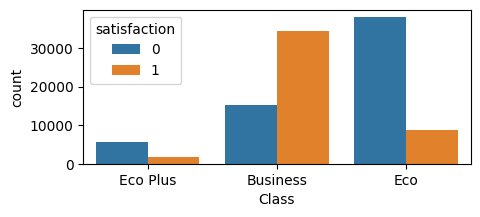

In [333]:
plt.figure(figsize = (5, 2))
sns.countplot(x = 'Class', data = df2, hue = 'satisfaction')

In [334]:
df2['Class'].value_counts()

,count
Class,
Business,49665
Eco,46745
Eco Plus,7494


In [335]:
ClassType = ohe.fit_transform(df2[['Class']]).toarray()
ClassType = pd.DataFrame(ClassType, columns = ['Business', 'Eco', 'Eco Plus'])

In [336]:
CustomerType = ohe.fit_transform(df2[['Customer Type']]).toarray()
CustomerType = pd.DataFrame(CustomerType, columns = ['Loyal Customer', 'disloyal Customer'])

In [337]:
TypeOfTravel = ohe.fit_transform(df2[['Type of Travel']]).toarray()
TypeOfTravel = pd.DataFrame(TypeOfTravel, columns = ['Business travel', 'Personal Travel'])

In [338]:
df2 = pd.concat([df2, ClassType, CustomerType, TypeOfTravel], axis = 1)

In [339]:
df2 = df2.drop({'Class', 'Customer Type', 'Type of Travel'}, axis = 1)

In [340]:
df2.head()

,Unnamed: 0,id,Gender,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,...,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,Business,Eco,Eco Plus,Loyal Customer,disloyal Customer,Business travel,Personal Travel
0,0,70172,1,13,460,3,4,3,1,5,...,25,18.0,0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
1,1,5047,1,25,235,3,2,3,3,1,...,1,6.0,0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
2,2,110028,0,26,1142,2,2,2,2,5,...,0,0.0,1,1.0,0.0,0.0,1.0,0.0,1.0,0.0
3,3,24026,0,25,562,2,5,5,5,2,...,11,9.0,0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,4,119299,1,61,214,3,3,3,3,4,...,0,0.0,1,1.0,0.0,0.0,1.0,0.0,1.0,0.0


In [341]:
X = df2.drop(['satisfaction', 'id', 'Unnamed: 0'], axis = 1)
y = df2['satisfaction']

In [342]:
X.shape

(103904, 26)

In [343]:
y.shape

(103904,)

In [344]:
from sklearn.preprocessing import MinMaxScaler

In [345]:
sc = MinMaxScaler()

In [346]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 42)

In [347]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(69615, 26)
(34289, 26)
(69615,)
(34289,)


In [348]:
X_train_Scaled = sc.fit_transform(X_train)
X_test_Scaled = sc.transform(X_test)

In [349]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [350]:
LR = LogisticRegression()
LR.fit(X_train_Scaled, y_train)
LR.score(X_test_Scaled, y_test)

0.8754994313045

Classification Report: 
               precision    recall  f1-score   support

           0       0.88      0.91      0.89     19334
           1       0.87      0.84      0.85     14955

    accuracy                           0.88     34289
   macro avg       0.88      0.87      0.87     34289
weighted avg       0.88      0.88      0.88     34289



<Axes: >

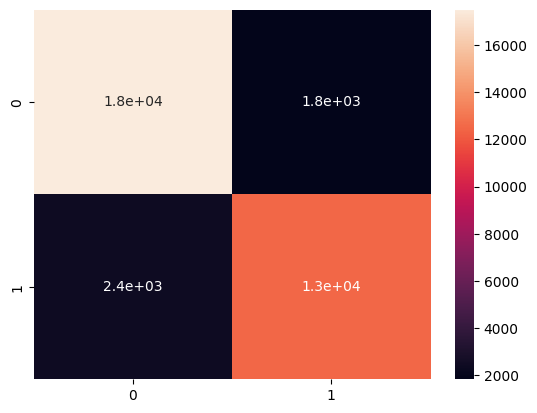

In [351]:
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y_test, LR.predict(X_test_Scaled))
print("Classification Report: \n", classification_report(y_test, LR.predict(X_test_Scaled)))
sns.heatmap(cm, annot = True)

In [352]:
dtc = DecisionTreeClassifier()
dtc.fit(X_train_Scaled, y_train)
dtc.score(X_test_Scaled, y_test)

0.946950917203768

In [353]:
# from sklearn.tree import plot_tree
# import matplotlib.pyplot as plt
# plt.figure(figsize=(12, 8))
# plot_tree(dtc,
#           feature_names=X_train.columns.tolist(), # Use column names from X_train DataFrame
#           class_names=['Not Satisfied', 'Satisfied'], # Provide meaningful class names
#           filled=True,
#           rounded=True,
#           impurity=True,
#           fontsize=10)
# plt.title("Decision Tree for Aviation Dataset")
# plt.show()

Classification Report: 
               precision    recall  f1-score   support

           0       0.95      0.95      0.95     19334
           1       0.94      0.94      0.94     14955

    accuracy                           0.95     34289
   macro avg       0.95      0.95      0.95     34289
weighted avg       0.95      0.95      0.95     34289



<Axes: >

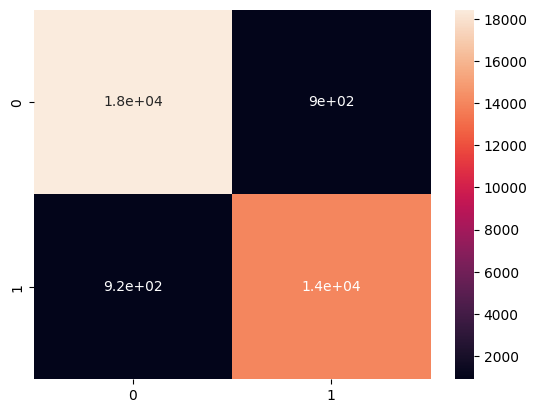

In [354]:
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y_test, dtc.predict(X_test_Scaled))
print("Classification Report: \n", classification_report(y_test, dtc.predict(X_test_Scaled)))
sns.heatmap(cm, annot = True)

In [355]:
rfc = RandomForestClassifier()
rfc.fit(X_train_Scaled, y_train)
rfc.score(X_test_Scaled, y_test)

0.9631077021785412

Classification Report: 
               precision    recall  f1-score   support

           0       0.96      0.98      0.97     19334
           1       0.97      0.94      0.96     14955

    accuracy                           0.96     34289
   macro avg       0.96      0.96      0.96     34289
weighted avg       0.96      0.96      0.96     34289



<Axes: >

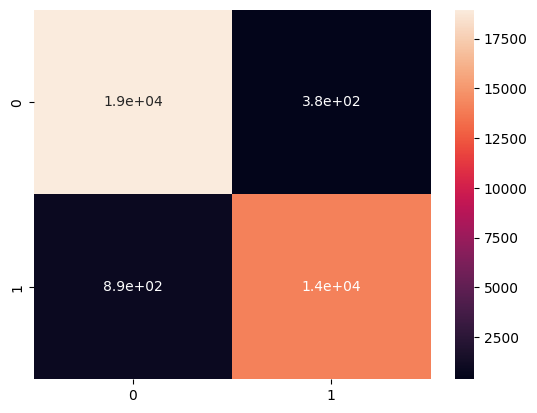

In [356]:
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y_test, rfc.predict(X_test_Scaled))
print("Classification Report: \n", classification_report(y_test, rfc.predict(X_test_Scaled)))
sns.heatmap(cm, annot = True)

In [357]:
abc = AdaBoostClassifier()
abc.fit(X_train_Scaled, y_train)
print(abc.score(X_train_Scaled, y_train))
print(abc.score(X_test_Scaled, y_test))

0.9100912159735689
0.9060631689463093


Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.93      0.92     19334
           1       0.91      0.87      0.89     14955

    accuracy                           0.91     34289
   macro avg       0.91      0.90      0.90     34289
weighted avg       0.91      0.91      0.91     34289



<Axes: >

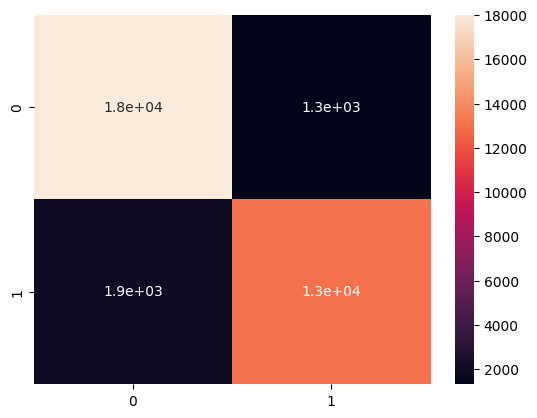

In [358]:
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y_test, abc.predict(X_test_Scaled))
print("Classification Report:\n", classification_report(y_test, abc.predict(X_test_Scaled)))
sns.heatmap(cm, annot = True)

In [359]:
gbc =  GradientBoostingClassifier()
gbc.fit(X_train_Scaled, y_train)
print(gbc.score(X_train_Scaled, y_train))
print(gbc.score(X_test_Scaled, y_test))

0.942095812684048
0.9421097144856951


Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.96      0.95     19334
           1       0.95      0.92      0.93     14955

    accuracy                           0.94     34289
   macro avg       0.94      0.94      0.94     34289
weighted avg       0.94      0.94      0.94     34289



<Axes: >

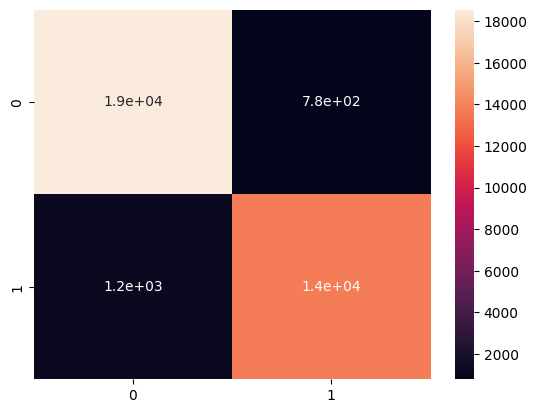

In [360]:
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y_test, gbc.predict(X_test_Scaled))
print("Classification Report:\n", classification_report(y_test, gbc.predict(X_test_Scaled)))
sns.heatmap(cm, annot = True)

In [361]:
gnb = GaussianNB()
gnb.fit(X_train_Scaled, y_train)
print(gnb.score(X_train_Scaled, y_train))
print(gnb.score(X_test_Scaled, y_test))

0.8489262371615313
0.8487853247397125


Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.88      0.87     19334
           1       0.83      0.81      0.82     14955

    accuracy                           0.85     34289
   macro avg       0.85      0.84      0.85     34289
weighted avg       0.85      0.85      0.85     34289



<Axes: >

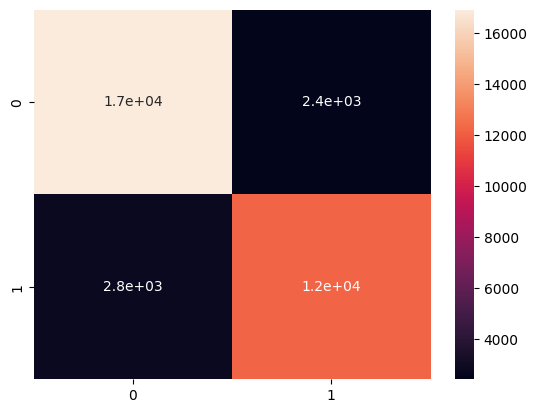

In [362]:
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y_test, gnb.predict(X_test_Scaled))
print("Classification Report:\n", classification_report(y_test, gnb.predict(X_test_Scaled)))
sns.heatmap(cm, annot = True)

In [363]:
# import matplotlib.pyplot as plt
# import numpy as np

# models = ["LR", "rfc", "dtc", "abc", "gnb", "gbc"]

# accuracy = [0.78, 0.85, 0.88, 0.80, 0.75, ]
# precision = [0.76, 0.83, 0.87, 0.78, 0.72]
# recall = [0.74, 0.82, 0.85, 0.79, 0.70]
# f1 = [0.75, 0.82, 0.86, 0.78, 0.71]

# x = np.arange(len(models))
# width = 0.2

# plt.figure(figsize=(12, 6))
# plt.bar(x - 0.3, accuracy, width, label="Accuracy")
# plt.bar(x - 0.1, precision, width, label="Precision")
# plt.bar(x + 0.1, recall, width, label="Recall")
# plt.bar(x + 0.3, f1, width, label="F1 Score")

# plt.xlabel("Models")
# plt.ylabel("Scores")
# plt.title("Model Performance Comparison")
# plt.xticks(x, models)
# plt.ylim(0, 1)
# plt.legend()
# plt.grid(axis='y')

# plt.show()

In [364]:
# s = SVC()
# s.fit(X_train_Scaled, y_train)
# print(s.score(X_train_Scaled, y_train))
# print(s.score(X_test_Scaled, y_test))

In [365]:
knn = KNeighborsClassifier()
knn.fit(X_train_Scaled, y_train)
print(knn.score(X_train_Scaled, y_train))
print(knn.score(X_test_Scaled, y_test))

0.9469510881275587
0.9258946017673306


Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.97      0.94     19334
           1       0.95      0.88      0.91     14955

    accuracy                           0.93     34289
   macro avg       0.93      0.92      0.92     34289
weighted avg       0.93      0.93      0.93     34289



<Axes: >

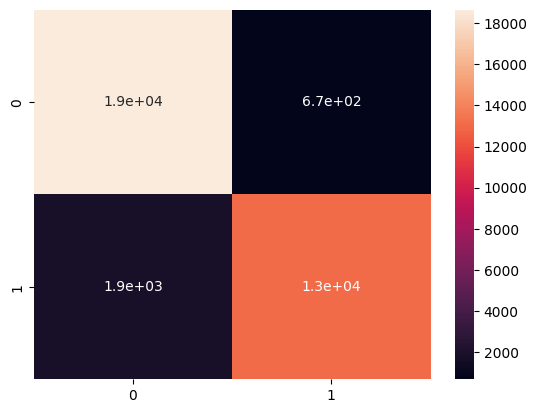

In [366]:
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y_test, knn.predict(X_test_Scaled))
print("Classification Report:\n", classification_report(y_test, knn.predict(X_test_Scaled)))
sns.heatmap(cm, annot = True)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but AdaBoostClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but GaussianNB was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feat

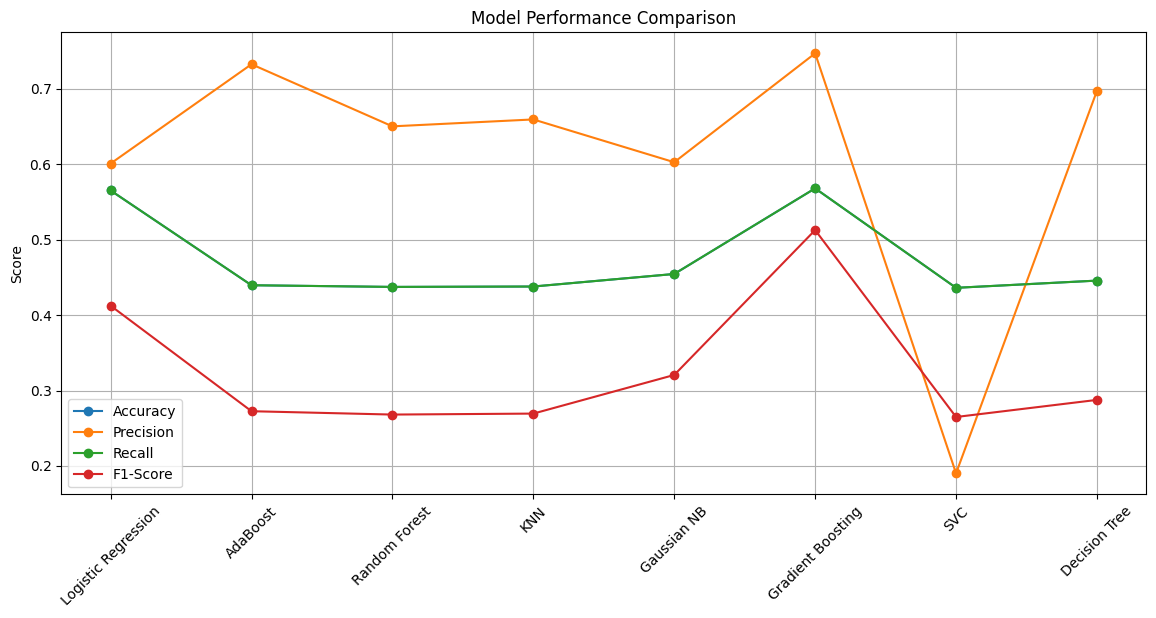

In [367]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
models = {
    "Logistic Regression": LR,
    "AdaBoost": abc,
    "Random Forest": rfc,
    "KNN": knn,
    "Gaussian NB": gnb,
    "Gradient Boosting": gbc,
    "SVC": s,
    "Decision Tree": dtc
}
metrics = {
    "Model": [],
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1-Score": []
}

for name, model in models.items():
    y_pred = model.predict(X_test)

    metrics["Model"].append(name)
    metrics["Accuracy"].append(accuracy_score(y_test, y_pred))
    metrics["Precision"].append(precision_score(y_test, y_pred, average='weighted'))
    metrics["Recall"].append(recall_score(y_test, y_pred, average='weighted'))
    metrics["F1-Score"].append(f1_score(y_test, y_pred, average='weighted'))

results_df = pd.DataFrame(metrics)
results_df

plt.figure(figsize=(14, 6))

x = range(len(results_df))

plt.plot(results_df["Model"], results_df["Accuracy"], marker='o', label="Accuracy")
plt.plot(results_df["Model"], results_df["Precision"], marker='o', label="Precision")
plt.plot(results_df["Model"], results_df["Recall"], marker='o', label="Recall")
plt.plot(results_df["Model"], results_df["F1-Score"], marker='o', label="F1-Score")

plt.xticks(rotation=45)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.grid(True)
plt.legend()
plt.show()

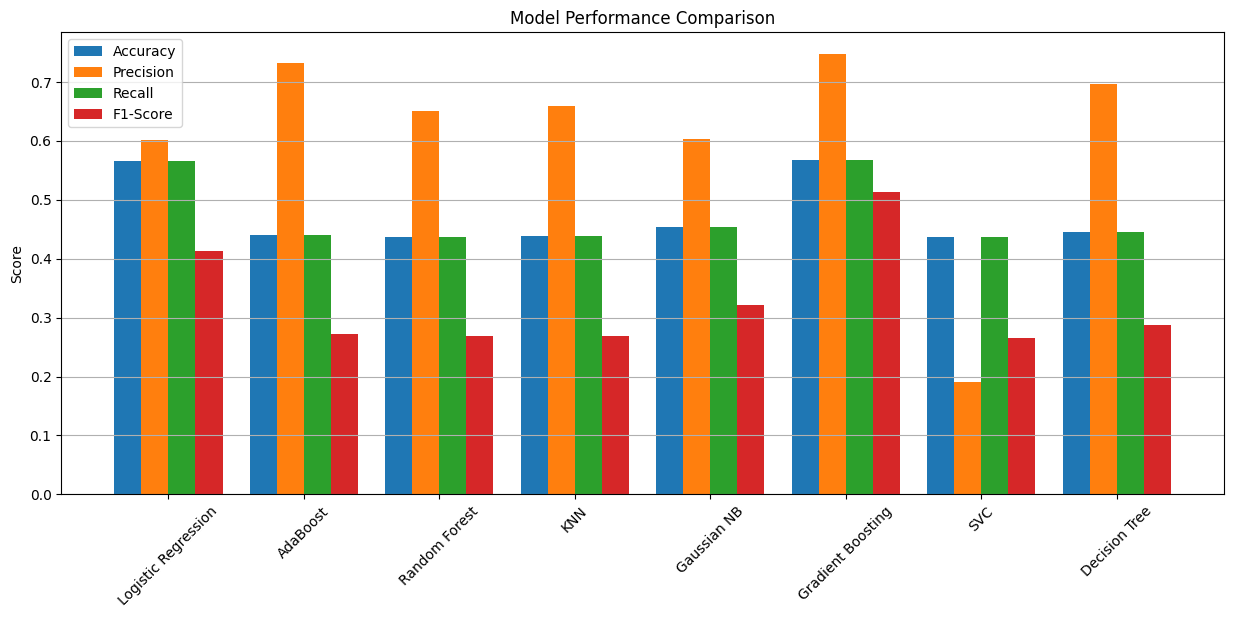

In [368]:
import numpy as np

plt.figure(figsize=(15, 6))

bar_width = 0.2
x = np.arange(len(results_df))

plt.bar(x - 0.3, results_df["Accuracy"], width=bar_width, label="Accuracy")
plt.bar(x - 0.1, results_df["Precision"], width=bar_width, label="Precision")
plt.bar(x + 0.1, results_df["Recall"], width=bar_width, label="Recall")
plt.bar(x + 0.3, results_df["F1-Score"], width=bar_width, label="F1-Score")

plt.xticks(x, results_df["Model"], rotation=45)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.legend()
plt.grid(axis='y')

plt.show()

In [369]:
from sklearn.decomposition import PCA

In [370]:
pca = PCA(n_components = 2)

In [371]:
data = {
    'Height': [170, 165, 180, 175, 160, 172, 168, 177, 162, 158],
    'Weight': [65, 59, 75, 68, 55, 70, 62, 74, 58, 54],
    'Age': [30, 25, 35, 28, 22, 32, 27, 33, 24, 21],
    'Gender': [1, 0, 1, 1, 0, 1, 0, 1, 0, 0]  # 1 = Male, 0 = Female
}
df = pd.DataFrame(data)
X = df.drop('Gender', axis=1)
y = df['Gender']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [372]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, random_state=42)
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

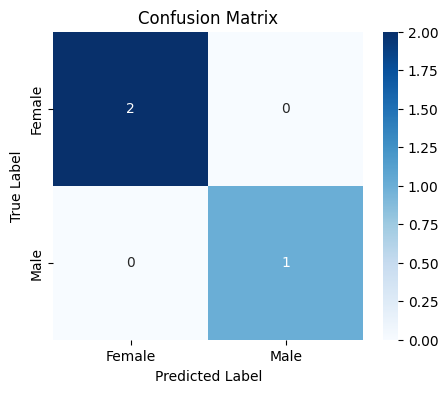

In [373]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Female', 'Male'], yticklabels=['Female', 'Male'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

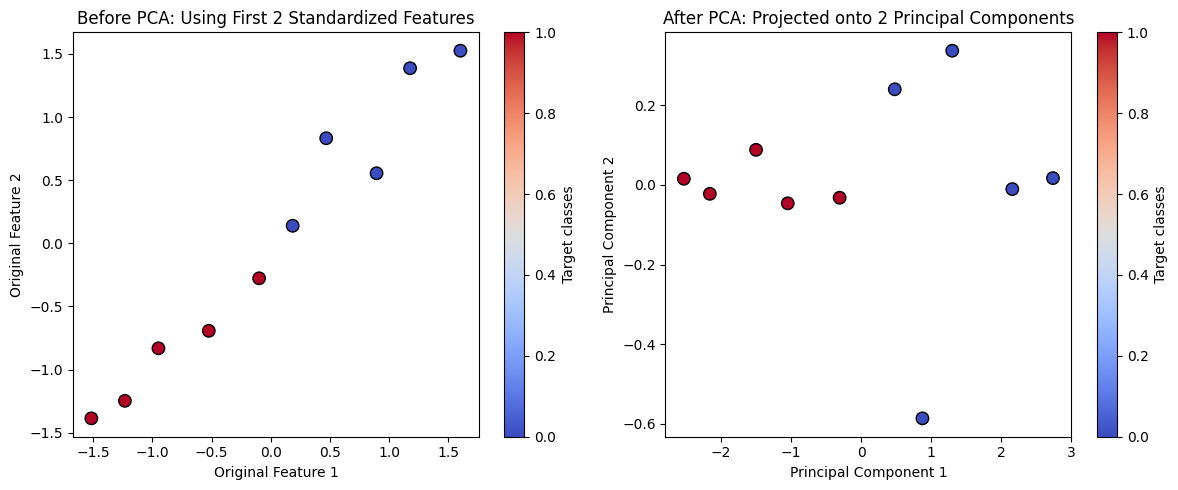

In [374]:
y_numeric = pd.factorize(y)[0]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_numeric, cmap='coolwarm', edgecolor='k', s=80)
plt.xlabel('Original Feature 1')
plt.ylabel('Original Feature 2')
plt.title('Before PCA: Using First 2 Standardized Features')
plt.colorbar(label='Target classes')

plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_numeric, cmap='coolwarm', edgecolor='k', s=80)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('After PCA: Projected onto 2 Principal Components')
plt.colorbar(label='Target classes')

plt.tight_layout()
plt.show()

In [375]:
import tensorflow as tf
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [376]:
X.shape

(10, 3)

In [377]:
y.shape

(10,)

In [378]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(7, 2)
(3, 2)
(7,)
(3,)


In [379]:
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

In [380]:
X_train_scaled.shape

(7, 2)

In [381]:
X_test_scaled.shape

(3, 2)

In [384]:
classifier = Sequential([Dense(32, activation = 'relu', input_shape = (7, )),
                         Dense(16, activation = 'relu'),
                         Dense(8, activation = 'relu'),
                         Dense(1, activation = 'sigmoid')])
classifier.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 32)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 929 (3.63 KB)

 Trainable params: 929 (3.63 KB)

 Non-trainable params: 0 (0.00 B)

In [386]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Redefine classifier with the corrected input_shape
classifier = Sequential([Dense(32, activation = 'relu', input_shape = (X_train_scaled.shape[1], )),
                         Dense(16, activation = 'relu'),
                         Dense(8, activation = 'relu'),
                         Dense(1, activation = 'sigmoid')])

classifier.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])
es = EarlyStopping(monitor = 'val_loss', patience = 5)
classifier.fit(X_train_scaled, y_train, validation_data = (X_test_scaled, y_test), epochs = 100, callbacks = [es])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step - accuracy: 0.4286 - loss: 0.8071 - val_accuracy: 0.6667 - val_loss: 0.7478
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.4286 - loss: 0.7965 - val_accuracy: 0.6667 - val_loss: 0.7415
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.4286 - loss: 0.7862 - val_accuracy: 0.6667 - val_loss: 0.7354
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.4286 - loss: 0.7761 - val_accuracy: 0.6667 - val_loss: 0.7295
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.4286 - loss: 0.7661 - val_accuracy: 0.6667 - val_loss: 0.7236
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.4286 - loss: 0.7564 - val_accuracy: 0.6667 - val_loss: 0.7178
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.4286 - loss: 0.7470 - val_accuracy: 0.6667 - val_loss: 0.7121
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.4286 - loss: 0.7378 - val_accuracy: 0.6667 - val_

In [387]:
preds = classifier.predict(X_test_scaled)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step


In [388]:
preds

array([[0.17563275],
       [0.23389201],
       [0.70759994]], dtype=float32)

In [389]:
preds_train = classifier.predict(X_train_scaled)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


In [391]:
preds_train

array([[0.6793739 ],
       [0.64582336],
       [0.66397095],
       [0.10238014],
       [0.12920359],
       [0.68678963],
       [0.32817444]], dtype=float32)

In [392]:
preds = (preds > 0.5)
preds_train = (preds_train > 0.5)

<Axes: >

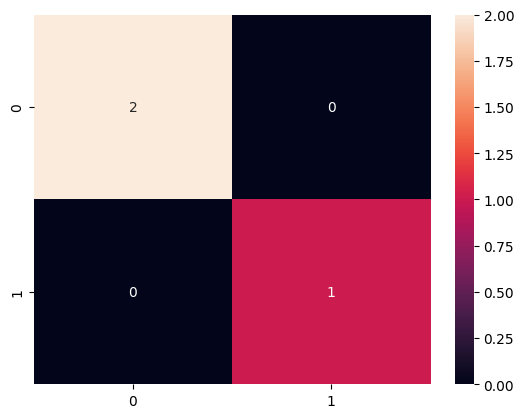

In [393]:
cm1 = confusion_matrix(preds, y_test)
sns.heatmap(cm1, annot = True)

<Axes: >

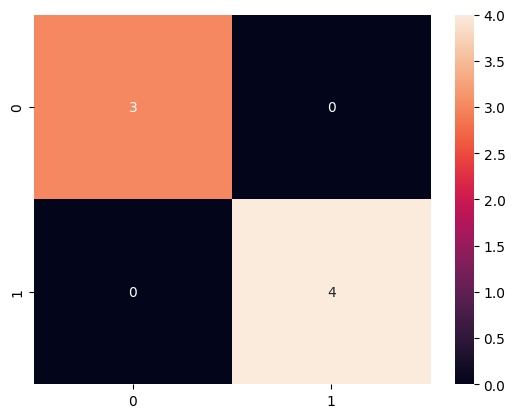

In [394]:
cm2 = confusion_matrix(preds_train, y_train)
sns.heatmap(cm2, annot = True)

In [395]:
print(classification_report(y_test, preds))
print(classification_report(y_train, preds_train))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         4

    accuracy                           1.00         7
   macro avg       1.00      1.00      1.00         7
weighted avg       1.00      1.00      1.00         7

